# Exploratory Data Analysis: Categorical Data

Categorical data represents groups, tags, or labels rather than raw numbers. To understand this, we will use a **hardware diagnostic log** tracking laptop repairs.
* **Brands:** HP, Dell, Acer.
* **Failures:** Screen Replacement, SSD Failure, BIOS Error.
* **Severity:** Low, Medium, High, Critical.

Before writing code, you must identify your category type:
* **Nominal:** Categories with no logical order (e.g., Laptop Brands).
* **Ordinal:** Categories with a strict, logical ranking (e.g., Severity Levels).

---

### 1. The Setup: Creating the Dataset
First, let's import our libraries and generate our raw diagnostic log. 

```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

# A sample of recent hardware diagnostics
repair_data = {
    'brand': ['HP', 'Dell', 'Acer', 'HP', 'Dell', 'Acer', 'HP', 'Dell'],
    'issue': ['Screen', 'SSD', 'BIOS', 'SSD', 'Screen', 'SSD', 'BIOS', 'SSD'],
    'severity': ['High', 'Critical', 'Low', 'Medium', 'Low', 'Critical', 'Medium', 'High']
}

df = pd.DataFrame(repair_data)
```


### 2. Converting to Categorical
By default, Pandas reads text as `object` (strings), which takes up excessive memory and cannot be sorted logically. Converting them to `category` types makes your code faster and smarter.

```python
# 1. Convert Nominal Data (Order does not matter)
df['brand'] = df['brand'].astype('category')
df['issue'] = df['issue'].astype('category')

# 2. Convert Ordinal Data (Order strictly matters)
# Define the exact logical sequence from lowest to highest
from pandas.api.types import CategoricalDtype

severity_order = CategoricalDtype(
    categories=['Low', 'Medium', 'High', 'Critical'], 
    ordered=True
)

df['severity'] = df['severity'].astype(severity_order)

# Verify the data types have changed
print(df.dtypes)
```

### 3. Analyzing Categorical Data
With our categories locked in, we can start extracting insights.

```python
# Insight 1: What is the most common issue we are repairing?
# Use .value_counts() to tally up a single column
print("--- Issue Tally ---")
issue_counts = df['issue'].value_counts()
print(issue_counts)

print("\n--- Brand vs. Issue Matrix ---")
# Insight 2: Are certain brands prone to specific failures?
# Use pd.crosstab() to compare two categories in a grid
brand_issues = pd.crosstab(df['brand'], df['issue'])
print(brand_issues)
```

### 4. Visualizing Categorical Data
While scatterplots are for continuous numbers, the **Count Plot** (a specialized bar chart) is the standard for visualizing categorical groups.

```python
# Create a count plot measuring severity, grouped by brand
sns.countplot(x='severity', hue='brand', data=df)

plt.title("Hardware Repair Severity by Laptop Brand")
plt.xlabel("Severity Level")
plt.ylabel("Number of Repairs")
plt.show()

### Exercise: Finding Unique Values in Categorical Columns

When dealing with a new dataset, it is crucial to understand how many distinct categories exist within your text columns. If a column has too many unique values (like 500 different airplane models), it might need to be grouped or cleaned before analysis.

In this exercise, we filter the dataset for text columns and loop through them to count their unique values.

#### Key Pandas Methods Used:

* select_dtypes(include="object"): Instantly creates a subset of your DataFrame containing only the text-based columns, ignoring all the math/number columns.

* .columns: Grabs the list of column headers to use in the for loop.

* .nunique(): Calculates the exact number of distinct categories in a column.

In [3]:
import pandas as pd

planes = pd.read_csv('planes.csv')

# 1. Filter the DataFrame for object (text/categorical) columns
non_numeric = planes.select_dtypes(include="object")

# 2. Loop through the names of those filtered columns
for col in non_numeric.columns:
  
  # 3. Print the number of unique values using .nunique()
  print(f"Number of unique values in {col} column: ", non_numeric[col].nunique())

Number of unique values in Airline column:  8
Number of unique values in Date_of_Journey column:  44
Number of unique values in Source column:  5
Number of unique values in Destination column:  6
Number of unique values in Route column:  126
Number of unique values in Dep_Time column:  221
Number of unique values in Arrival_Time column:  1334
Number of unique values in Duration column:  367
Number of unique values in Total_Stops column:  5
Number of unique values in Additional_Info column:  10


C:\Users\user\AppData\Local\Temp\ipykernel_9776\544596178.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_numeric = planes.select_dtypes(include="object")


### Filtering Categorical Time Strings

When using the `|` (OR) operator to search for multiple string patterns, we must use the `^` anchor. This forces the search to only look at the first characters of the string, preventing double-digit hours (like "10h") from accidentally triggering single-digit rules (like "0h").

In [ ]:

# Create a list of categories
flight_categories = ["Short-haul", "Medium", "Long-haul"]

# Create short-haul values using the start anchor (^)
short_flights = "^0h|^1h|^2h|^3h|^4h"

# Create medium-haul values
medium_flights = "^5h|^6h|^7h|^8h|^9h"

# Create long-haul values
long_flights = "^10h|^11h|^12h|^13h|^14h|^15h|^16h"

### Applying Categories and Visualizing the Results

Once we have defined our string patterns (like `short_flights`), we use Pandas string methods to search for them, and `numpy` to build a new categorized column based on what it finds. Finally, we visualize the distribution of our new categories.

```python


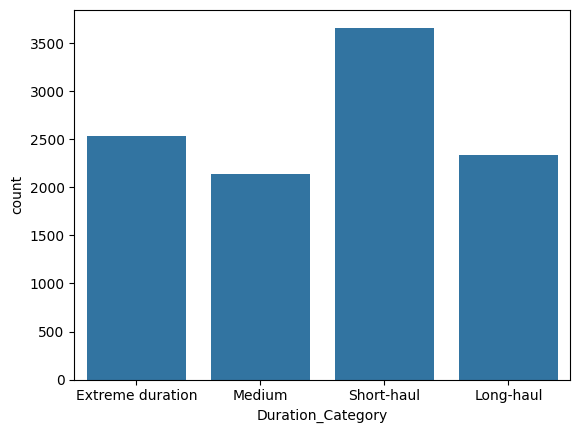

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

planes = pd.read_csv('planes.csv')


# Create a list of categories
flight_categories = ["Short-haul", "Medium", "Long-haul"]

# Create short-haul values using the start anchor (^)
short_flights = "^0h|^1h|^2h|^3h|^4h"

# Create medium-haul values
medium_flights = "^5h|^6h|^7h|^8h|^9h"

# Create long-haul values
long_flights = "^10h|^11h|^12h|^13h|^14h|^15h|^16h"


# Create conditions for values in flight_categories to be created
# We use .str.contains() to check if the Duration string matches our regex patterns
conditions = [
    (planes["Duration"].str.contains(short_flights)),
    (planes["Duration"].str.contains(medium_flights)),
    (planes["Duration"].str.contains(long_flights))
]

# Apply the conditions list to the flight_categories
# np.select acts like a massive IF/ELSE statement. 
planes["Duration_Category"] = np.select(conditions, 
                                        flight_categories,
                                        default="Extreme duration")

# Plot the counts of each category
# sns.countplot is the standard for visualising categorical frequency
sns.countplot(data=planes, x="Duration_Category")
plt.show()

# Exploratory Data Analysis: Numerical Data

If categorical data is about *grouping* things, numerical data is about *measuring* things. In Exploratory Data Analysis (EDA), your main goals with numerical data are to find the center (averages), measure the spread (how wide the data ranges), and hunt down outliers (weird anomalies).

### 1. Summary Statistics (The `.describe()` Method)
When you have a column of 10,000 prices, you cannot read them one by one. The very first thing a data scientist does is run a summary to get a bird's-eye view. This instantly calculates:
* **Mean:** The mathematical average.
* **Median (50%):** The exact middle number if you lined them all up. (This is often more reliable than the mean because it does not get tricked by extreme outliers).
* **Min/Max:** The absolute lowest and highest values in your dataset.
* **Standard Deviation (std):** A measure of how "spread out" the numbers are from the average.

### 2. Visualizing Distributions (The Histogram)
Numbers in a table are hard to visualize. A **Histogram** takes your numbers, groups them into "bins" (like buckets), and counts how many fall into each bucket. This shows you the *shape* of your data.
* If it looks like a symmetrical bell, it is a "Normal Distribution."
* If it leans heavily to one side with a long tail, it is "Skewed." 

### 3. Spotting Outliers (The Boxplot)
Outliers are extreme values that can ruin your machine learning models (like a $2,000 first-class ticket in a dataset of normal $250 economy flights). 
A **Boxplot** is a specialized chart designed specifically to find outliers. It draws a box around the middle 50% of your data, lines (whiskers) to the normal upper and lower edges, and plots any extreme outliers as individual, floating dots so you can immediately identify them.

--- Summary Statistics ---
       Flight_ID        Price  Distance_Miles
count   7.000000     7.000000        7.000000
mean    4.000000   527.142857     1007.142857
std     2.160247   649.813160      888.551523
min     1.000000   250.000000      500.000000
25%     2.500000   270.000000      575.000000
50%     4.000000   290.000000      750.000000
75%     5.500000   305.000000      825.000000
max     7.000000  2000.000000     3000.000000




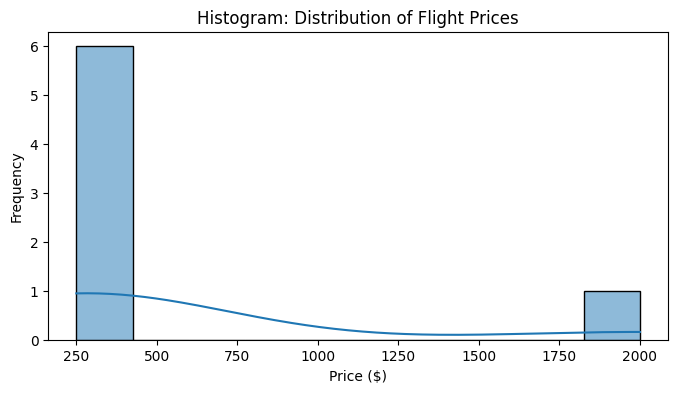

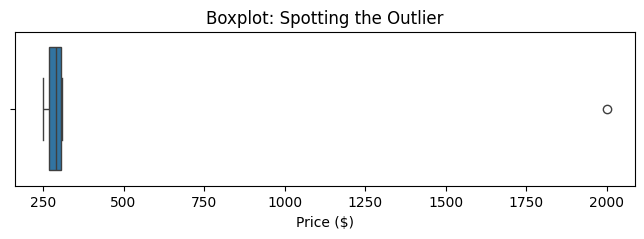

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create Sample Numerical Data (Notice the extreme $2000 outlier)
flights = pd.DataFrame({
    'Flight_ID': [1, 2, 3, 4, 5, 6, 7],
    'Price': [250, 280, 310, 290, 260, 300, 2000], 
    'Distance_Miles': [500, 600, 850, 750, 550, 800, 3000]
})

# 2. Generate Summary Statistics
print("--- Summary Statistics ---")
print(flights.describe())
print("\n" + "="*40 + "\n")

# 3. Plot a Histogram to see the distribution
plt.figure(figsize=(8, 4))
# 'bins' determines how many buckets to divide the data into
sns.histplot(flights['Price'], bins=10, kde=True)
plt.title("Histogram: Distribution of Flight Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

# 4. Plot a Boxplot to easily spot outliers
plt.figure(figsize=(8, 2))
sns.boxplot(x=flights['Price'])
plt.title("Boxplot: Spotting the Outlier")
plt.xlabel("Price ($)")
plt.show()